In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [2]:
!cp "/content/drive/MyDrive/deepfake_project.zip" /content/


In [3]:
!unzip -q deepfake_project.zip -d /content/dataset


In [4]:
import os

for root, dirs, files in os.walk("/content/dataset"):
    print("Folders:", dirs)
    break


Folders: ['RealVsFake']


In [5]:
import os

for root, dirs, files in os.walk("/content/dataset/RealVsFake"):
    print("Folders:", dirs)
    break


Folders: ['RealVsFake']


In [6]:
import os

for root, dirs, files in os.walk("/content/dataset/RealVsFake/RealVsFake"):
    print("Folders:", dirs)
    break


Folders: ['Real', 'Fake']


In [7]:
import os

real_count = len(os.listdir("/content/dataset/RealVsFake/Real"))
fake_count = len(os.listdir("/content/dataset/RealVsFake/Fake"))

print("Real images:", real_count)
print("Fake images:", fake_count)


FileNotFoundError: [Errno 2] No such file or directory: '/content/dataset/RealVsFake/Real'

In [8]:
!ls /content/dataset


RealVsFake  test_labels.csv  train_labels.csv  val_labels.csv


In [9]:
!ls /content/dataset/RealVsFake


RealVsFake


In [10]:
!ls /content/dataset/RealVsFake


RealVsFake


In [11]:
!ls /content/dataset/RealVsFake/RealVsFake


Fake  Real


In [12]:
import os

real_path = "/content/dataset/RealVsFake/RealVsFake/Real"
fake_path = "/content/dataset/RealVsFake/RealVsFake/Fake"

real_count = len(os.listdir(real_path))
fake_count = len(os.listdir(fake_path))

print("Real images:", real_count)
print("Fake images:", fake_count)


Real images: 81000
Fake images: 80972


In [13]:
import os
import shutil
import random

base_path = "/content/dataset/RealVsFake/RealVsFake"
output_path = "/content/working_dataset"

os.makedirs(output_path, exist_ok=True)

classes = ["Real", "Fake"]

for cls in classes:
    src = os.path.join(base_path, cls)
    dst = os.path.join(output_path, cls)
    os.makedirs(dst, exist_ok=True)

    images = os.listdir(src)
    random.shuffle(images)

    selected_images = images[:20000]  # Select 20k

    for img in selected_images:
        shutil.copy(os.path.join(src, img), os.path.join(dst, img))

print("Subset Created ✅")


Subset Created ✅


In [14]:
import os
import shutil
import random

split_path = "/content/split_dataset"
base_path = "/content/working_dataset"

classes = ["Real", "Fake"]

for cls in classes:
    os.makedirs(f"{split_path}/train/{cls}", exist_ok=True)
    os.makedirs(f"{split_path}/val/{cls}", exist_ok=True)

    images = os.listdir(f"{base_path}/{cls}")
    random.shuffle(images)

    split_index = int(0.8 * len(images))

    train_imgs = images[:split_index]
    val_imgs = images[split_index:]

    for img in train_imgs:
        shutil.copy(f"{base_path}/{cls}/{img}",
                    f"{split_path}/train/{cls}/{img}")

    for img in val_imgs:
        shutil.copy(f"{base_path}/{cls}/{img}",
                    f"{split_path}/val/{cls}/{img}")

print("Train/Validation Split Complete ✅")


Train/Validation Split Complete ✅


In [15]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import os

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# Data preprocessing
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.5,0.5,0.5], [0.5,0.5,0.5])
])

train_dataset = datasets.ImageFolder("/content/split_dataset/train", transform=transform)
val_dataset = datasets.ImageFolder("/content/split_dataset/val", transform=transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32)

print("Train samples:", len(train_dataset))
print("Validation samples:", len(val_dataset))


Using device: cuda
Train samples: 32000
Validation samples: 8000


In [17]:
import timm
import torch.nn as nn

model = timm.create_model("efficientnet_b0", pretrained=True)
model.classifier = nn.Linear(model.classifier.in_features, 2)
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

print("Model Ready 🚀")


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/21.4M [00:00<?, ?B/s]

Model Ready 🚀


In [18]:
best_val_acc = 0

for epoch in range(5):

    # -------- TRAIN --------
    model.train()
    train_loss = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    train_loss /= len(train_loader)

    # -------- VALIDATE --------
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (preds == labels).sum().item()

    val_acc = 100 * correct / total

    print(f"Epoch {epoch+1}")
    print(f"Train Loss: {train_loss:.4f}")
    print(f"Validation Accuracy: {val_acc:.2f}%")
    print("-"*30)

    # Save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "/content/best_model.pth")

print("Best Validation Accuracy:", best_val_acc)


Epoch 1
Train Loss: 0.0641
Validation Accuracy: 99.70%
------------------------------
Epoch 2
Train Loss: 0.0103
Validation Accuracy: 99.88%
------------------------------
Epoch 3
Train Loss: 0.0043
Validation Accuracy: 99.84%
------------------------------
Epoch 4
Train Loss: 0.0042
Validation Accuracy: 99.91%
------------------------------
Epoch 5
Train Loss: 0.0030
Validation Accuracy: 99.91%
------------------------------
Best Validation Accuracy: 99.9125


In [20]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

print(classification_report(all_labels, all_preds))
print("Confusion Matrix:\n", confusion_matrix(all_labels, all_preds))


              precision    recall  f1-score   support

           0       1.00      1.00      1.00      4000
           1       1.00      1.00      1.00      4000

    accuracy                           1.00      8000
   macro avg       1.00      1.00      1.00      8000
weighted avg       1.00      1.00      1.00      8000

Confusion Matrix:
 [[3996    4]
 [   3 3997]]


In [22]:
!pip install grad-cam



     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 58.9 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for grad-cam: filename=grad_cam-1.5.5-py3-none-any.whl size=44285 sha256=f06492fc5e9424848f16fbccde0a6104ba070ed189b3cc6f599912cce8385ead
  Stored in directory: /root/.cache/pip/wheels/fb/3b/09/2afc520f3d69bc26ae6bd87416759c820a3f7d05c1a077bbf6
Successfully built grad-cam


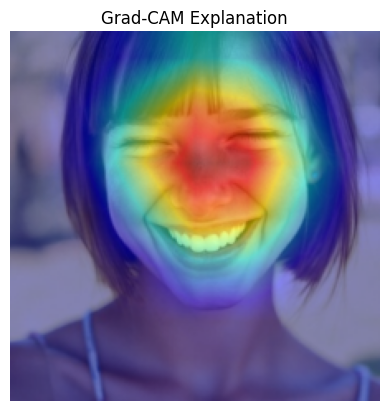

In [23]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image
import matplotlib.pyplot as plt
import numpy as np
import torch

model.eval()

# Correct target layer for EfficientNet-B0 (timm)
target_layer = model.conv_head

cam = GradCAM(model=model, target_layers=[target_layer])

# Get one validation image
image, label = next(iter(val_loader))
input_tensor = image[0].unsqueeze(0).to(device)

# Generate CAM
grayscale_cam = cam(input_tensor=input_tensor,
                    targets=[ClassifierOutputTarget(label[0].item())])

heatmap = grayscale_cam[0]

# Prepare image for visualization
img = image[0].permute(1,2,0).numpy()
img = (img - img.min()) / (img.max() - img.min())

visualization = show_cam_on_image(img, heatmap, use_rgb=True)

plt.imshow(visualization)
plt.title("Grad-CAM Explanation")
plt.axis("off")
plt.show()


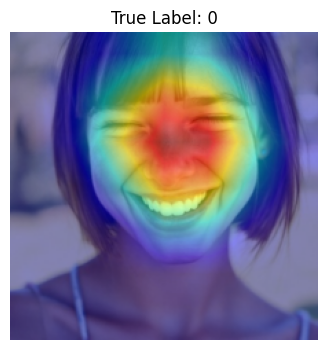

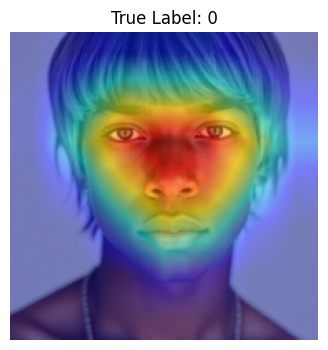

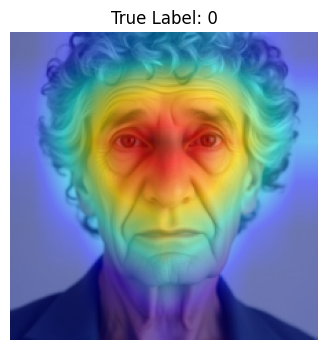

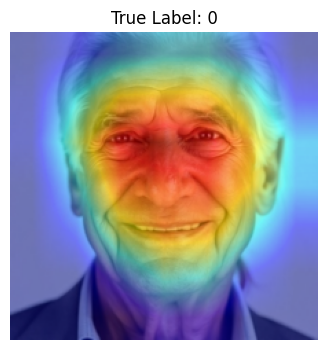

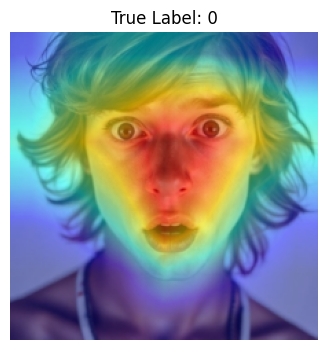

In [24]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image
import matplotlib.pyplot as plt
import numpy as np
import torch

model.eval()
target_layer = model.conv_head
cam = GradCAM(model=model, target_layers=[target_layer])

# Get one batch
images, labels = next(iter(val_loader))

for i in range(5):  # visualize 5 images
    input_tensor = images[i].unsqueeze(0).to(device)

    grayscale_cam = cam(input_tensor=input_tensor,
                        targets=[ClassifierOutputTarget(labels[i].item())])

    heatmap = grayscale_cam[0]

    img = images[i].permute(1,2,0).numpy()
    img = (img - img.min()) / (img.max() - img.min())

    visualization = show_cam_on_image(img, heatmap, use_rgb=True)

    plt.figure(figsize=(4,4))
    plt.imshow(visualization)
    plt.title(f"True Label: {labels[i].item()}")
    plt.axis("off")
    plt.show()


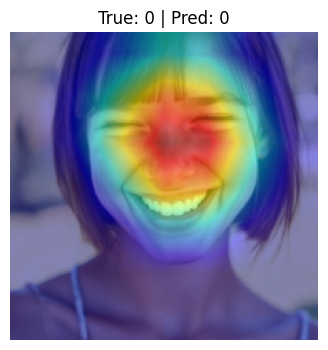

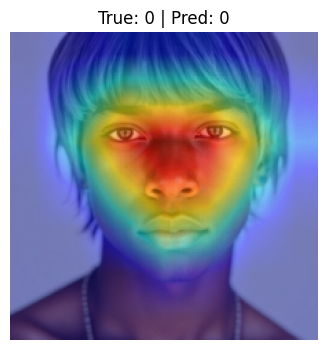

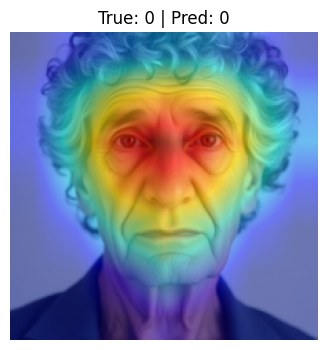

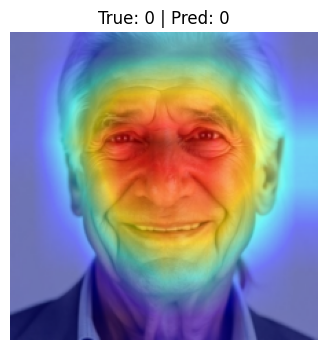

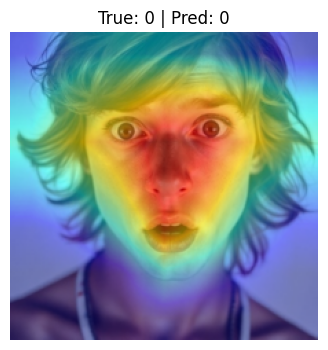

In [26]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image
import matplotlib.pyplot as plt
import numpy as np
import torch

model.eval()

# Better target layer for EfficientNet
target_layer = model.blocks[-1]

cam = GradCAM(model=model, target_layers=[target_layer])

images, labels = next(iter(val_loader))
images = images.to(device)

# Do NOT wrap in torch.no_grad() for GradCAM
outputs = model(images)
_, preds = torch.max(outputs, 1)

for i in range(5):
    input_tensor = images[i].unsqueeze(0)

    grayscale_cam = cam(
        input_tensor=input_tensor,
        targets=[ClassifierOutputTarget(preds[i].item())]
    )

    heatmap = grayscale_cam[0]

    img = images[i].detach().cpu().permute(1,2,0).numpy()
    img = (img - img.min()) / (img.max() - img.min())

    visualization = show_cam_on_image(img, heatmap, use_rgb=True)

    plt.figure(figsize=(4,4))
    plt.imshow(visualization)
    plt.title(f"True: {labels[i].item()} | Pred: {preds[i].item()}")
    plt.axis("off")
    plt.show()


In [27]:
print(train_dataset.class_to_idx)


{'Fake': 0, 'Real': 1}


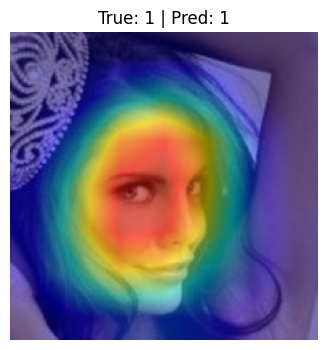

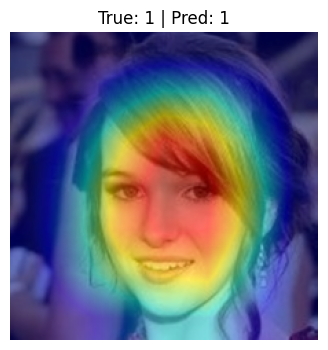

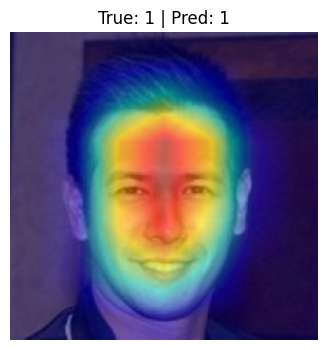

In [28]:
count = 0

for images, labels in val_loader:
    for i in range(len(labels)):
        if labels[i].item() == 1:  # Real images
            input_tensor = images[i].unsqueeze(0).to(device)

            outputs = model(input_tensor)
            _, pred = torch.max(outputs, 1)

            grayscale_cam = cam(
                input_tensor=input_tensor,
                targets=[ClassifierOutputTarget(pred.item())]
            )

            heatmap = grayscale_cam[0]

            img = images[i].permute(1,2,0).numpy()
            img = (img - img.min()) / (img.max() - img.min())

            visualization = show_cam_on_image(img, heatmap, use_rgb=True)

            plt.figure(figsize=(4,4))
            plt.imshow(visualization)
            plt.title(f"True: {labels[i].item()} | Pred: {pred.item()}")
            plt.axis("off")
            plt.show()

            count += 1
            if count == 3:
                break
    if count == 3:
        break


In [29]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

def extract_fft(image_tensor):
    # Convert tensor to numpy image
    img = image_tensor.permute(1,2,0).cpu().numpy()
    img = (img - img.min()) / (img.max() - img.min())

    gray = cv2.cvtColor((img*255).astype(np.uint8), cv2.COLOR_RGB2GRAY)

    # FFT
    f = np.fft.fft2(gray)
    fshift = np.fft.fftshift(f)
    magnitude = 20 * np.log(np.abs(fshift) + 1)

    # Normalize
    magnitude = (magnitude - magnitude.min()) / (magnitude.max() - magnitude.min())

    return magnitude


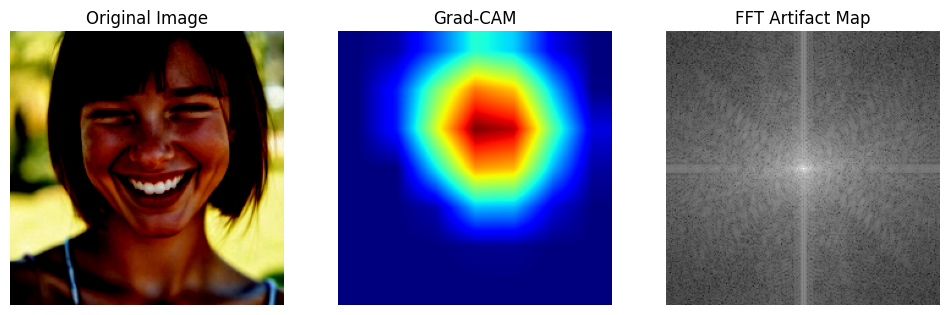

In [30]:
# Find one fake image
for images, labels in val_loader:
    for i in range(len(labels)):
        if labels[i].item() == 0:  # Fake
            img_tensor = images[i]
            break
    break

# Generate Grad-CAM
input_tensor = img_tensor.unsqueeze(0).to(device)

grayscale_cam = cam(
    input_tensor=input_tensor,
    targets=[ClassifierOutputTarget(0)]
)

gradcam_map = grayscale_cam[0]

# Generate FFT
fft_map = extract_fft(img_tensor)

# Plot side by side
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(img_tensor.permute(1,2,0))
plt.title("Original Image")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(gradcam_map, cmap='jet')
plt.title("Grad-CAM")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(fft_map, cmap='gray')
plt.title("FFT Artifact Map")
plt.axis("off")

plt.show()


In [31]:
import torch.nn.functional as F
import torch

# Resize FFT to Grad-CAM size
fft_tensor = torch.tensor(fft_map).float().unsqueeze(0).unsqueeze(0)
fft_resized = F.interpolate(
    fft_tensor,
    size=gradcam_map.shape,
    mode='bilinear',
    align_corners=False
).squeeze()

grad_tensor = torch.tensor(gradcam_map).float()

# Normalize
fft_resized = (fft_resized - fft_resized.min()) / (fft_resized.max() - fft_resized.min())
grad_tensor = (grad_tensor - grad_tensor.min()) / (grad_tensor.max() - grad_tensor.min())

# Compute overlap (cosine similarity)
alignment_score = F.cosine_similarity(
    grad_tensor.flatten(),
    fft_resized.flatten(),
    dim=0
)

print("Alignment Score:", alignment_score.item())


Alignment Score: 0.6865870356559753


In [32]:
import torch.nn.functional as F
import torch
import numpy as np

fake_scores = []
real_scores = []

count = 0

for images, labels in val_loader:
    for i in range(len(labels)):
        img_tensor = images[i]
        label = labels[i].item()

        input_tensor = img_tensor.unsqueeze(0).to(device)

        grayscale_cam = cam(
            input_tensor=input_tensor,
            targets=[ClassifierOutputTarget(label)]
        )
        grad_map = torch.tensor(grayscale_cam[0]).float()

        fft_map = extract_fft(img_tensor)
        fft_tensor = torch.tensor(fft_map).float().unsqueeze(0).unsqueeze(0)
        fft_resized = F.interpolate(
            fft_tensor,
            size=grad_map.shape,
            mode='bilinear',
            align_corners=False
        ).squeeze()

        # Normalize
        grad_map = (grad_map - grad_map.min()) / (grad_map.max() - grad_map.min())
        fft_resized = (fft_resized - fft_resized.min()) / (fft_resized.max() - fft_resized.min())

        score = F.cosine_similarity(
            grad_map.flatten(),
            fft_resized.flatten(),
            dim=0
        ).item()

        if label == 0:
            fake_scores.append(score)
        else:
            real_scores.append(score)

        count += 1
        if count == 50:  # test on 50 images first
            break
    if count == 50:
        break

print("Average Fake Alignment:", np.mean(fake_scores))
print("Average Real Alignment:", np.mean(real_scores))


Average Fake Alignment: 0.8054757392406464
Average Real Alignment: nan


/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:3596: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


In [33]:
import torch.nn.functional as F
import torch
import numpy as np

fake_scores = []
real_scores = []

for images, labels in val_loader:
    for i in range(len(labels)):
        img_tensor = images[i]
        label = labels[i].item()

        input_tensor = img_tensor.unsqueeze(0).to(device)

        grayscale_cam = cam(
            input_tensor=input_tensor,
            targets=[ClassifierOutputTarget(label)]
        )
        grad_map = torch.tensor(grayscale_cam[0]).float()

        fft_map = extract_fft(img_tensor)
        fft_tensor = torch.tensor(fft_map).float().unsqueeze(0).unsqueeze(0)
        fft_resized = F.interpolate(
            fft_tensor,
            size=grad_map.shape,
            mode='bilinear',
            align_corners=False
        ).squeeze()

        # Normalize
        grad_map = (grad_map - grad_map.min()) / (grad_map.max() - grad_map.min())
        fft_resized = (fft_resized - fft_resized.min()) / (fft_resized.max() - fft_resized.min())

        score = F.cosine_similarity(
            grad_map.flatten(),
            fft_resized.flatten(),
            dim=0
        ).item()

        if label == 0 and len(fake_scores) < 50:
            fake_scores.append(score)
        elif label == 1 and len(real_scores) < 50:
            real_scores.append(score)

        if len(fake_scores) >= 50 and len(real_scores) >= 50:
            break

    if len(fake_scores) >= 50 and len(real_scores) >= 50:
        break

print("Average Fake Alignment:", np.mean(fake_scores))
print("Average Real Alignment:", np.mean(real_scores))


Average Fake Alignment: 0.8054757392406464
Average Real Alignment: 0.7916019427776336


In [34]:
import timm
import torch.nn as nn
import torch

class ArtifactAwareEfficientNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = timm.create_model("efficientnet_b0", pretrained=True)
        self.features = self.model.forward_features
        self.pool = self.model.global_pool
        self.classifier = nn.Linear(self.model.classifier.in_features, 2)

    def forward(self, x):
        feature_map = self.features(x)   # convolutional features
        pooled = self.pool(feature_map)
        logits = self.classifier(pooled)
        return logits, feature_map

model = ArtifactAwareEfficientNet().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

print("Artifact-Aware Model Ready 🚀")


Artifact-Aware Model Ready 🚀


In [35]:
import torch.nn.functional as F
import numpy as np

lambda_artifact = 0.3
best_val_acc = 0

for epoch in range(3):

    model.train()
    running_loss = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        logits, feature_maps = model(images)

        classification_loss = criterion(logits, labels)

        # Compute attention map from feature maps
        attention_map = torch.mean(feature_maps, dim=1)

        attention_map = F.interpolate(
            attention_map.unsqueeze(1),
            size=(224,224),
            mode='bilinear',
            align_corners=False
        ).squeeze(1)

        # Compute FFT artifact maps batch-wise
        artifact_maps = []
        for img in images:
            img_np = img.detach().cpu().permute(1,2,0).numpy()
            img_np = (img_np - img_np.min())/(img_np.max()-img_np.min())
            gray = cv2.cvtColor((img_np*255).astype(np.uint8), cv2.COLOR_RGB2GRAY)

            f = np.fft.fft2(gray)
            fshift = np.fft.fftshift(f)
            magnitude = 20*np.log(np.abs(fshift)+1)
            magnitude = (magnitude - magnitude.min())/(magnitude.max()-magnitude.min())

            artifact_maps.append(torch.tensor(magnitude))

        artifact_maps = torch.stack(artifact_maps).to(device)

        # Normalize attention
        attention_map = (attention_map - attention_map.min())/(attention_map.max()-attention_map.min())

        # Resize artifact maps
        artifact_maps = F.interpolate(
            artifact_maps.unsqueeze(1),
            size=(224,224),
            mode='bilinear',
            align_corners=False
        ).squeeze(1)

        artifact_maps = (artifact_maps - artifact_maps.min())/(artifact_maps.max()-artifact_maps.min())

        # Artifact alignment loss
        artifact_loss = 1 - F.cosine_similarity(
            attention_map.flatten(start_dim=1),
            artifact_maps.flatten(start_dim=1),
            dim=1
        ).mean()

        total_loss = classification_loss + lambda_artifact * artifact_loss

        optimizer.zero_grad()
        total_loss.backward()
        optimizer.step()

        running_loss += total_loss.item()

    print(f"Epoch {epoch+1} Loss: {running_loss/len(train_loader)}")


Epoch 1 Loss: 0.07627747708451485
Epoch 2 Loss: 0.013168863015687654
Epoch 3 Loss: 0.009952527059898904


In [36]:
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in val_loader:
        images, labels = images.to(device), labels.to(device)
        logits, _ = model(images)
        _, preds = torch.max(logits, 1)

        total += labels.size(0)
        correct += (preds == labels).sum().item()

val_acc = 100 * correct / total
print("Artifact-Aware Validation Accuracy:", val_acc)


Artifact-Aware Validation Accuracy: 99.9625


In [37]:
import torch.nn.functional as F
import torch
import numpy as np

fake_scores = []
real_scores = []

model.eval()

for images, labels in val_loader:
    for i in range(len(labels)):
        img_tensor = images[i]
        label = labels[i].item()

        input_tensor = img_tensor.unsqueeze(0).to(device)

        logits, feature_map = model(input_tensor)

        # Attention map from feature map
        attention_map = torch.mean(feature_map, dim=1)

        attention_map = F.interpolate(
            attention_map.unsqueeze(1),
            size=(224,224),
            mode='bilinear',
            align_corners=False
        ).squeeze()

        attention_map = (attention_map - attention_map.min()) / (attention_map.max() - attention_map.min())

        # FFT artifact map
        img_np = img_tensor.detach().cpu().permute(1,2,0).numpy()
        img_np = (img_np - img_np.min())/(img_np.max()-img_np.min())
        gray = cv2.cvtColor((img_np*255).astype(np.uint8), cv2.COLOR_RGB2GRAY)

        f = np.fft.fft2(gray)
        fshift = np.fft.fftshift(f)
        magnitude = 20*np.log(np.abs(fshift)+1)
        magnitude = (magnitude - magnitude.min())/(magnitude.max()-magnitude.min())

        artifact_map = torch.tensor(magnitude).float().to(device)

        # Resize artifact map
        artifact_map = F.interpolate(
            artifact_map.unsqueeze(0).unsqueeze(0),
            size=(224,224),
            mode='bilinear',
            align_corners=False
        ).squeeze()

        artifact_map = (artifact_map - artifact_map.min()) / (artifact_map.max() - artifact_map.min())

        score = F.cosine_similarity(
            attention_map.flatten(),
            artifact_map.flatten(),
            dim=0
        ).item()

        if label == 0 and len(fake_scores) < 50:
            fake_scores.append(score)
        elif label == 1 and len(real_scores) < 50:
            real_scores.append(score)

        if len(fake_scores) >= 50 and len(real_scores) >= 50:
            break

    if len(fake_scores) >= 50 and len(real_scores) >= 50:
        break

print("Artifact-Aware Fake Alignment:", np.mean(fake_scores))
print("Artifact-Aware Real Alignment:", np.mean(real_scores))


Artifact-Aware Fake Alignment: 0.9421939575672149
Artifact-Aware Real Alignment: 0.963334914445877


In [38]:
import numpy as np
import cv2

def extract_high_freq_fft(image_tensor, mask_radius_ratio=0.15):
    img = image_tensor.permute(1,2,0).cpu().numpy()
    img = (img - img.min()) / (img.max() - img.min())

    gray = cv2.cvtColor((img*255).astype(np.uint8), cv2.COLOR_RGB2GRAY)

    f = np.fft.fft2(gray)
    fshift = np.fft.fftshift(f)

    rows, cols = gray.shape
    crow, ccol = rows//2 , cols//2

    # Create mask that removes low-frequency center
    mask = np.ones((rows, cols), np.uint8)
    radius = int(mask_radius_ratio * min(rows, cols))

    y, x = np.ogrid[:rows, :cols]
    center_mask = (x - ccol)**2 + (y - crow)**2 <= radius**2
    mask[center_mask] = 0

    # Apply mask
    fshift_masked = fshift * mask

    magnitude = 20 * np.log(np.abs(fshift_masked) + 1)
    magnitude = (magnitude - magnitude.min()) / (magnitude.max() - magnitude.min())

    return magnitude


In [39]:
fft_map = extract_high_freq_fft(img_tensor)


In [40]:
import torch.nn.functional as F
import torch
import numpy as np

fake_scores = []
real_scores = []

model.eval()

for images, labels in val_loader:
    for i in range(len(labels)):
        img_tensor = images[i]
        label = labels[i].item()

        input_tensor = img_tensor.unsqueeze(0).to(device)

        logits, feature_map = model(input_tensor)

        # Attention map from feature map
        attention_map = torch.mean(feature_map, dim=1)

        attention_map = F.interpolate(
            attention_map.unsqueeze(1),
            size=(224,224),
            mode='bilinear',
            align_corners=False
        ).squeeze()

        attention_map = (attention_map - attention_map.min()) / (attention_map.max() - attention_map.min())

        # High-frequency FFT artifact map
        fft_map = extract_high_freq_fft(img_tensor)
        artifact_map = torch.tensor(fft_map).float().to(device)

        artifact_map = F.interpolate(
            artifact_map.unsqueeze(0).unsqueeze(0),
            size=(224,224),
            mode='bilinear',
            align_corners=False
        ).squeeze()

        artifact_map = (artifact_map - artifact_map.min()) / (artifact_map.max() - artifact_map.min())

        score = F.cosine_similarity(
            attention_map.flatten(),
            artifact_map.flatten(),
            dim=0
        ).item()

        if label == 0 and len(fake_scores) < 50:
            fake_scores.append(score)
        elif label == 1 and len(real_scores) < 50:
            real_scores.append(score)

        if len(fake_scores) >= 50 and len(real_scores) >= 50:
            break

    if len(fake_scores) >= 50 and len(real_scores) >= 50:
        break

print("High-Freq Fake Alignment:", np.mean(fake_scores))
print("High-Freq Real Alignment:", np.mean(real_scores))


High-Freq Fake Alignment: 0.8544480633735657
High-Freq Real Alignment: 0.8473035192489624


In [41]:
model = ArtifactAwareEfficientNet().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)


In [42]:
import torch.nn.functional as F
import numpy as np
import cv2

lambda_artifact = 0.3
best_val_acc = 0

for epoch in range(3):

    model.train()
    running_loss = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        logits, feature_maps = model(images)

        classification_loss = criterion(logits, labels)

        # Attention map from feature maps
        attention_map = torch.mean(feature_maps, dim=1)

        attention_map = F.interpolate(
            attention_map.unsqueeze(1),
            size=(224,224),
            mode='bilinear',
            align_corners=False
        ).squeeze(1)

        attention_map = (attention_map - attention_map.min()) / (attention_map.max() - attention_map.min())

        artifact_losses = []

        for i in range(len(labels)):

            # Apply artifact loss ONLY for Fake (label = 0)
            if labels[i].item() == 0:

                img = images[i]
                img_np = img.detach().cpu().permute(1,2,0).numpy()
                img_np = (img_np - img_np.min())/(img_np.max()-img_np.min())
                gray = cv2.cvtColor((img_np*255).astype(np.uint8), cv2.COLOR_RGB2GRAY)

                f = np.fft.fft2(gray)
                fshift = np.fft.fftshift(f)

                rows, cols = gray.shape
                crow, ccol = rows//2 , cols//2

                # High-frequency mask
                mask = np.ones((rows, cols), np.uint8)
                radius = int(0.15 * min(rows, cols))

                y, x = np.ogrid[:rows, :cols]
                center_mask = (x - ccol)**2 + (y - crow)**2 <= radius**2
                mask[center_mask] = 0

                fshift_masked = fshift * mask
                magnitude = 20*np.log(np.abs(fshift_masked)+1)
                magnitude = (magnitude - magnitude.min())/(magnitude.max()-magnitude.min())

                artifact_map = torch.tensor(magnitude).float().to(device)

                artifact_map = F.interpolate(
                    artifact_map.unsqueeze(0).unsqueeze(0),
                    size=(224,224),
                    mode='bilinear',
                    align_corners=False
                ).squeeze()

                artifact_map = (artifact_map - artifact_map.min()) / (artifact_map.max() - artifact_map.min())

                # Cosine similarity loss
                score = F.cosine_similarity(
                    attention_map[i].flatten(),
                    artifact_map.flatten(),
                    dim=0
                )

                artifact_losses.append(1 - score)

        if len(artifact_losses) > 0:
            artifact_loss = torch.stack(artifact_losses).mean()
        else:
            artifact_loss = torch.tensor(0.0).to(device)

        total_loss = classification_loss + lambda_artifact * artifact_loss

        optimizer.zero_grad()
        total_loss.backward()
        optimizer.step()

        running_loss += total_loss.item()

    print(f"Epoch {epoch+1} Loss: {running_loss/len(train_loader)}")


Epoch 1 Loss: 0.08012999999616295
Epoch 2 Loss: 0.01867458995664492
Epoch 3 Loss: 0.012104872093070299


In [43]:
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in val_loader:
        images, labels = images.to(device), labels.to(device)
        logits, _ = model(images)
        _, preds = torch.max(logits, 1)

        total += labels.size(0)
        correct += (preds == labels).sum().item()

print("Fake-Only Artifact Validation Accuracy:", 100 * correct / total)


Fake-Only Artifact Validation Accuracy: 99.9125


In [45]:
import torch.nn.functional as F
import torch
import numpy as np

fake_scores = []
real_scores = []

model.eval()

for images, labels in val_loader:
    for i in range(len(labels)):
        img_tensor = images[i]
        label = labels[i].item()

        input_tensor = img_tensor.unsqueeze(0).to(device)

        logits, feature_map = model(input_tensor)

        attention_map = torch.mean(feature_map, dim=1)

        attention_map = F.interpolate(
            attention_map.unsqueeze(1),
            size=(224,224),
            mode='bilinear',
            align_corners=False
        ).squeeze()

        attention_map = (attention_map - attention_map.min()) / (attention_map.max() - attention_map.min())

        # High-frequency FFT
        fft_map = extract_high_freq_fft(img_tensor)
        artifact_map = torch.tensor(fft_map).float().to(device)

        artifact_map = F.interpolate(
            artifact_map.unsqueeze(0).unsqueeze(0),
            size=(224,224),
            mode='bilinear',
            align_corners=False
        ).squeeze()

        artifact_map = (artifact_map - artifact_map.min()) / (artifact_map.max() - artifact_map.min())

        score = F.cosine_similarity(
            attention_map.flatten(),
            artifact_map.flatten(),
            dim=0
        ).item()

        if label == 0 and len(fake_scores) < 50:
            fake_scores.append(score)
        elif label == 1 and len(real_scores) < 50:
            real_scores.append(score)

        if len(fake_scores) >= 50 and len(real_scores) >= 50:
            break

    if len(fake_scores) >= 50 and len(real_scores) >= 50:
        break

print("High-Freq Fake Alignment:", np.mean(fake_scores))
print("High-Freq Real Alignment:", np.mean(real_scores))
print("Gap:", np.mean(fake_scores) - np.mean(real_scores))


High-Freq Fake Alignment: 0.9602970826625824
High-Freq Real Alignment: 0.6985933053493499
Gap: 0.26170377731323247


In [46]:
torch.save(model.state_dict(), "fake_only_artifact_model.pth")


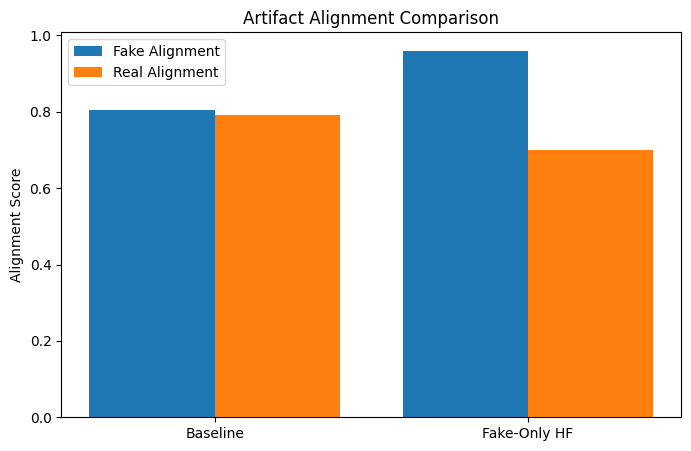

In [47]:
import matplotlib.pyplot as plt

models = ["Baseline", "Fake-Only HF"]
fake_align = [0.805, 0.960]
real_align = [0.792, 0.699]

x = range(len(models))

plt.figure(figsize=(8,5))
plt.bar(x, fake_align, width=0.4, label="Fake Alignment")
plt.bar([i + 0.4 for i in x], real_align, width=0.4, label="Real Alignment")

plt.xticks([i + 0.2 for i in x], models)
plt.ylabel("Alignment Score")
plt.title("Artifact Alignment Comparison")
plt.legend()
plt.show()


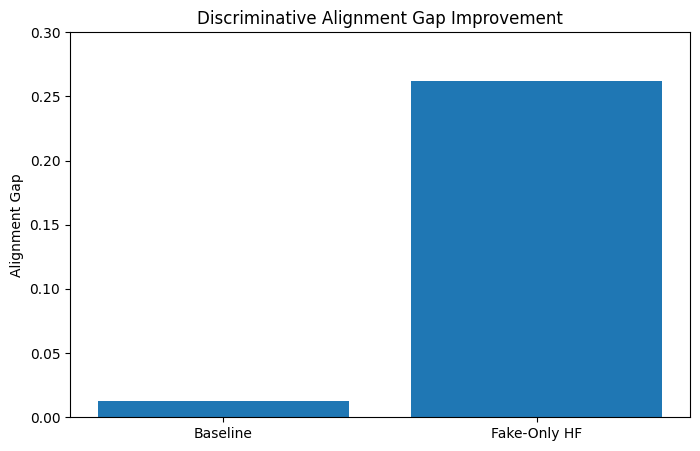

In [52]:
plt.figure(figsize=(8,5))
plt.bar(["Baseline", "Fake-Only HF"], [0.013, 0.262])
plt.ylabel("Alignment Gap")
plt.title("Discriminative Alignment Gap Improvement")
plt.ylim(0,0.3)
plt.savefig("alignment_gap_comparison.png", dpi=300, bbox_inches='tight')
plt.show()


In [53]:
plt.savefig("alignment_gap_improvement.png", dpi=300, bbox_inches="tight")


<Figure size 640x480 with 0 Axes>